# TCN Regression with Enhanced Features (Climate + Soil + Interactive + Categorical)

## Overview
This notebook builds a Temporal Convolutional Network (TCN) model that combines:
- **Climate features** (temperature, rainfall, humidity, etc.)
- **Soil features** (pH, nitrogen, phosphorus, potassium, etc.)
- **Interactive features** (climate × soil combinations)
- **Categorical features** (crop type, region, zone)

The TCN includes ReLU activation to prevent negative yield predictions.

**Expected Improvement:** Better feature combination should improve R² beyond baseline TCN.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import json
import warnings
warnings.filterwarnings('ignore')

# TensorFlow and Keras
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, optimizers, callbacks, regularizers
from tensorflow.keras.layers import Input, Conv1D, BatchNormalization, Dropout, Dense, GlobalAveragePooling1D, concatenate
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.optimizers import Adam, RMSprop
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.metrics import RootMeanSquaredError

# Preprocessing
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import time

print("✅ Libraries imported successfully")
print(f"TensorFlow version: {tf.__version__}")
print(f"Keras version: {keras.__version__}")

✅ Libraries imported successfully
TensorFlow version: 2.20.0
Keras version: 3.13.0


## Section 1: Load and Prepare Climate Data

In [2]:
# Set paths
BASE_PATH = Path('.')
DATA_PATH = BASE_PATH / 'project_data' / 'processed_data'
MODELS_PATH = BASE_PATH / 'models'

# Load master data
print("📊 Loading data...")
data = pd.read_csv(DATA_PATH / 'master_data_hybrid.csv')

print(f"\nDataset shape: {data.shape}")
print(f"Columns: {data.columns.tolist()}\n")

# Display basic info
print("Dataset Info:")
print(f"  Crops: {data['Crop'].unique()}")
print(f"  Regions: {data['Region'].unique()}")
print(f"  Yield range: {data['Yield_kg_per_ha'].min():.2f} - {data['Yield_kg_per_ha'].max():.2f} kg/ha")
print(f"  Missing values: {data.isnull().sum().sum()}")

# Climate features - typical weather variables
climate_features = [col for col in data.columns if any(x in col.lower() for x in 
    ['temp', 'rain', 'humidity', 'wind', 'precip', 'pressure', 'solar', 'et0', 'rh', 'tmean', 'tmax', 'tmin'])]

print(f"\n🌡️ Climate features found: {len(climate_features)}")
print(f"Examples: {climate_features[:5]}")

# Extract climate data
if climate_features:
    climate_data = data[climate_features].copy()
    print(f"Climate data shape: {climate_data.shape}")
else:
    print("⚠️ No climate features found, using all numeric columns")
    climate_data = data.select_dtypes(include=[np.number]).drop('Yield_kg_per_ha', axis=1, errors='ignore').copy()

# Normalize climate data
scaler_climate = StandardScaler()
climate_normalized = scaler_climate.fit_transform(climate_data)
print(f"✅ Climate features normalized")


📊 Loading data...

Dataset shape: (3456, 35)
Columns: ['Region', 'Crop', 'Year', 'Month', 'Temperature_C', 'Rainfall_mm', 'Humidity_percent', 'CO2_ppm', 'Avg_pH', 'Avg_Nitrogen_ppm', 'Avg_Phosphorus_ppm', 'Avg_Organic_Matter_Percent', 'Yield_kg_per_ha', 'GDD', 'Cumulative_Rainfall', 'Days_Into_Season', 'pH_Temperature_Interaction', 'Nitrogen_Rainfall_Interaction', 'Is_Rainy_Season', 'Is_Peak_Growing', 'Heat_Stress', 'Cold_Stress', 'Rainfall_Anomaly', 'Drought_Risk', 'Flood_Risk', 'Yield_Lag_1', 'Yield_Lag_2', 'Yield_Lag_3', 'Yield_MA_3yr', 'Temp_MA_3yr', 'Rain_MA_3yr', 'Yield_YoY_Change', 'Temp_YoY_Change', 'Rain_YoY_Change', 'Yield_Volatility_3yr']

Dataset Info:
  Crops: ['Cassava' 'Yams']
  Regions: ['North Central' 'North East' 'North West' 'South East' 'South South'
 'South West']
  Yield range: 0.00 - 3.74 kg/ha
  Missing values: 0

🌡️ Climate features found: 12
Examples: ['Temperature_C', 'Rainfall_mm', 'Humidity_percent', 'Cumulative_Rainfall', 'pH_Temperature_Interaction']
Cli

## Section 2: Load and Prepare Soil Data

In [5]:
# Soil features - typical soil properties (numeric only)
soil_feature_keywords = ['soil', 'ph', 'nitrogen', 'phosphorus', 'potassium', 'silt', 'sand', 'clay', 'organic', 'cation', 'n', 'p', 'k', 'om', 'ec']
soil_features = [col for col in data.select_dtypes(include=[np.number]).columns if any(x in col.lower() for x in soil_feature_keywords)]

print(f"🌱 Soil features found: {len(soil_features)}")
print(f"Examples: {soil_features[:5]}")

# Extract soil data
if soil_features:
    soil_data = data[soil_features].copy()
    print(f"Soil data shape: {soil_data.shape}")
else:
    print("⚠️ No specific soil features, creating synthetic ones from remaining numeric columns")
    # If no soil features, use remaining numeric columns (exclude climate and target)
    used_cols = set(climate_features) | {'Yield_kg_per_ha'}
    soil_data = data.select_dtypes(include=[np.number]).drop(list(used_cols), axis=1, errors='ignore').copy()
    
    if soil_data.shape[1] == 0:
        print("⚠️ No additional numeric columns found, using zeros")
        soil_data = pd.DataFrame(np.zeros((len(data), 1)), columns=['synthetic_soil'])

# Handle missing values in soil data
soil_data = soil_data.fillna(soil_data.mean(numeric_only=True))

# Normalize soil data
scaler_soil = StandardScaler()
soil_normalized = scaler_soil.fit_transform(soil_data)
print(f"✅ Soil features normalized")
print(f"Final soil shape: {soil_normalized.shape}")


🌱 Soil features found: 24
Examples: ['Month', 'Temperature_C', 'Rainfall_mm', 'Humidity_percent', 'CO2_ppm']
Soil data shape: (3456, 24)
✅ Soil features normalized
Final soil shape: (3456, 24)


## Section 3: Create Interactive Features

In [6]:
# Create interactive features by combining climate and soil
print("🔄 Creating interactive features (Climate × Soil combinations)...")

# Select key climate and soil features for interactions
n_climate = min(3, climate_normalized.shape[1])  # Top 3 climate features
n_soil = min(3, soil_normalized.shape[1])  # Top 3 soil features

interactive_features = []

# Create multiplicative interactions
for i in range(n_climate):
    for j in range(n_soil):
        interaction = climate_normalized[:, i] * soil_normalized[:, j]
        interactive_features.append(interaction)

# Create additive interactions
for i in range(n_climate):
    for j in range(n_soil):
        interaction = climate_normalized[:, i] + soil_normalized[:, j]
        interactive_features.append(interaction)

# Convert to array and normalize
if interactive_features:
    interactive_array = np.column_stack(interactive_features)
    scaler_interactive = StandardScaler()
    interactive_normalized = scaler_interactive.fit_transform(interactive_array)
    print(f"✅ Interactive features created: {interactive_normalized.shape[1]} features")
else:
    interactive_normalized = np.array([]).reshape(len(climate_normalized), 0)
    print("⚠️ No interactive features created (insufficient data)")


🔄 Creating interactive features (Climate × Soil combinations)...
✅ Interactive features created: 18 features


## Section 4: Encode Categorical Variables

In [7]:
# Encode categorical variables
print("🏷️ Encoding categorical features...")

categorical_cols = ['Crop', 'Region', 'State', 'Zone']
categorical_data = []
encoders = {}

for col in categorical_cols:
    if col in data.columns:
        encoder = LabelEncoder()
        encoded = encoder.fit_transform(data[col].astype(str))
        categorical_data.append(encoded)
        encoders[col] = encoder
        print(f"  {col}: {len(encoder.classes_)} unique values")

# Stack categorical features
if categorical_data:
    categorical_array = np.column_stack(categorical_data)
    
    # One-hot encode categorical features
    from sklearn.preprocessing import OneHotEncoder
    onehot_encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
    categorical_onehot = onehot_encoder.fit_transform(categorical_array)
    
    print(f"✅ Categorical features one-hot encoded: {categorical_onehot.shape[1]} features")
else:
    categorical_onehot = np.array([]).reshape(len(climate_normalized), 0)
    print("⚠️ No categorical features found")

# Store target variable
target = data['Yield_kg_per_ha'].values
scaler_y = StandardScaler()
target_scaled = scaler_y.fit_transform(target.reshape(-1, 1)).flatten()

print(f"\n✅ Target variable prepared")
print(f"  Yield range: {target.min():.2f} - {target.max():.2f} kg/ha")


🏷️ Encoding categorical features...
  Crop: 2 unique values
  Region: 6 unique values
✅ Categorical features one-hot encoded: 8 features

✅ Target variable prepared
  Yield range: 0.00 - 3.74 kg/ha


## Section 5: Combine All Features

In [8]:
# Combine all features
print("\n" + "="*80)
print("COMBINING ALL FEATURE TYPES")
print("="*80)

print(f"\nFeature Shapes:")
print(f"  Climate:      {climate_normalized.shape}")
print(f"  Soil:         {soil_normalized.shape}")
print(f"  Interactive:  {interactive_normalized.shape}")
print(f"  Categorical:  {categorical_onehot.shape}")

# Concatenate all features horizontally
combined_features = np.concatenate([
    climate_normalized,
    soil_normalized,
    interactive_normalized,
    categorical_onehot
], axis=1)

print(f"\n✅ Combined features shape: {combined_features.shape}")
print(f"   Total features: {combined_features.shape[1]}")

# Create sequences for TCN
# TCN expects input shape: (batch_size, timesteps, features)
# We'll use 6 timestep sequences
sequence_length = 6
n_features = combined_features.shape[1]

def create_sequences(data, target, seq_length=6):
    """Create overlapping sequences for time series data"""
    sequences = []
    targets = []
    
    for i in range(len(data) - seq_length + 1):
        seq = data[i:i + seq_length]
        sequences.append(seq)
        # Use the last target in the sequence
        targets.append(target[i + seq_length - 1])
    
    return np.array(sequences), np.array(targets)

# Create sequences
X, y = create_sequences(combined_features, target_scaled, sequence_length)

print(f"\n📊 Sequence Creation:")
print(f"   Sequence length: {sequence_length}")
print(f"   Total sequences: {len(X)}")
print(f"   Input shape: {X.shape}  (batch, timesteps, features)")
print(f"   Target shape: {y.shape}")

# Train/Val/Test split
from sklearn.model_selection import train_test_split

X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.15, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.15/0.85, random_state=42)

print(f"\n✅ Data Split:")
print(f"   Train: {X_train.shape[0]} samples ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"   Val:   {X_val.shape[0]} samples ({X_val.shape[0]/len(X)*100:.1f}%)")
print(f"   Test:  {X_test.shape[0]} samples ({X_test.shape[0]/len(X)*100:.1f}%)")

# Inverse transform for original scale metrics later
y_train_orig = scaler_y.inverse_transform(y_train.reshape(-1, 1)).flatten()
y_val_orig = scaler_y.inverse_transform(y_val.reshape(-1, 1)).flatten()
y_test_orig = scaler_y.inverse_transform(y_test.reshape(-1, 1)).flatten()

print(f"\n✅ Ready for TCN training!")



COMBINING ALL FEATURE TYPES

Feature Shapes:
  Climate:      (3456, 12)
  Soil:         (3456, 24)
  Interactive:  (3456, 18)
  Categorical:  (3456, 8)

✅ Combined features shape: (3456, 62)
   Total features: 62

📊 Sequence Creation:
   Sequence length: 6
   Total sequences: 3451
   Input shape: (3451, 6, 62)  (batch, timesteps, features)
   Target shape: (3451,)

✅ Data Split:
   Train: 2415 samples (70.0%)
   Val:   518 samples (15.0%)
   Test:  518 samples (15.0%)

✅ Ready for TCN training!


## Section 6: Build TCN Model with ReLU Activation

In [9]:
print("\n" + "="*80)
print("BUILDING TCN MODEL WITH ReLU ACTIVATION")
print("="*80)

def build_tcn_with_enhanded_features():
    """
    Build TCN model with:
    - Climate features
    - Soil features
    - Interactive features (climate × soil)
    - Categorical features
    - ReLU activation to prevent negative predictions
    """
    inputs = layers.Input(shape=(sequence_length, n_features), name='input_combined_features')
    
    # TCN Block 1: Dilated Conv1D layers
    x = layers.Conv1D(
        filters=128,
        kernel_size=3,
        dilation_rate=1,
        padding='causal',
        activation='relu',
        kernel_regularizer=regularizers.l2(1e-5),
        name='tcn_conv1d_1'
    )(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.2)(x)
    
    # TCN Block 2: Dilated Conv1D with dilation=2
    x = layers.Conv1D(
        filters=128,
        kernel_size=3,
        dilation_rate=2,
        padding='causal',
        activation='relu',
        kernel_regularizer=regularizers.l2(1e-5),
        name='tcn_conv1d_2'
    )(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.2)(x)
    
    # TCN Block 3: Dilated Conv1D with dilation=4
    x = layers.Conv1D(
        filters=64,
        kernel_size=3,
        dilation_rate=4,
        padding='causal',
        activation='relu',
        kernel_regularizer=regularizers.l2(1e-5),
        name='tcn_conv1d_3'
    )(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.15)(x)
    
    # Global pooling
    x = layers.GlobalAveragePooling1D()(x)
    
    # Dense layers
    x = layers.Dense(
        128,
        activation='relu',
        kernel_regularizer=regularizers.l2(1e-5),
        name='dense_1'
    )(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.25)(x)
    
    x = layers.Dense(
        64,
        activation='relu',
        kernel_regularizer=regularizers.l2(1e-5),
        name='dense_2'
    )(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.2)(x)
    
    x = layers.Dense(32, activation='relu', name='dense_3')(x)
    
    # Output layer with ReLU to prevent negative yields
    outputs = layers.Dense(1, activation='relu', name='yield_output')(x)
    
    model = models.Model(inputs=inputs, outputs=outputs, name='TCN_Enhanced_Features')
    return model

# Build model
model = build_tcn_with_enhanded_features()

print("\n✅ TCN Model Created")
print(f"\nModel Architecture:")
print(f"  Input shape: {X_train.shape} (batch_size, timesteps={sequence_length}, features={n_features})")
model.summary()

# Compile model
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='mse',
    metrics=['mae', RootMeanSquaredError()]
)

print("\n✅ Model compiled with Adam optimizer")



BUILDING TCN MODEL WITH ReLU ACTIVATION

✅ TCN Model Created

Model Architecture:
  Input shape: (2415, 6, 62) (batch_size, timesteps=6, features=62)


Model: "TCN_Enhanced_Features"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_combined_features         │ (None, 6, 62)          │             0 │
│ (InputLayer)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ tcn_conv1d_1 (Conv1D)           │ (None, 6, 128)         │        23,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 6, 128)         │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 6, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ tcn_conv1d_2 (Conv1D)           │ (None, 6, 128)         │        49,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 6, 128)         │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 6, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ tcn_conv1d_3 (Conv1D)           │ (None, 6, 64)          │        24,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 6, 64)          │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 6, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ yield_output (Dense)            │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 118,593 (463.25 KB)

 Trainable params: 117,569 (459.25 KB)

 Non-trainable params: 1,024 (4.00 KB)


✅ Model compiled with Adam optimizer


## Section 7: Train the TCN Model


TRAINING TCN MODEL

⏳ Training started...
   Epochs: up to 200 (with early stopping)
   Batch size: 32
   Validation split: 518 samples

Epoch 1/200


76/76 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.4470 - mae: 0.5335 - root_mean_squared_error: 0.6648 - val_loss: 0.4161 - val_mae: 0.4843 - val_root_mean_squared_error: 0.6411 - learning_rate: 5.0000e-04
Epoch 2/200
76/76 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.4464 - mae: 0.5303 - root_mean_squared_error: 0.6643 - val_loss: 0.4249 - val_mae: 0.4860 - val_root_mean_squared_error: 0.6479 - learning_rate: 5.0000e-04
Epoch 3/200
76/76 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.4474 - mae: 0.5304 - root_mean_squared_error: 0.6650 - val_loss: 0.4155 - val_mae: 0.4861 - val_root_mean_squared_error: 0.6406 - learning_rate: 5.0000e-04
Epoch 4/200
76/76 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.4449 - mae: 0.5291 - root_mean_squared_error: 0.6632 - val_loss: 0.4165 - val_mae: 0.4832 - val_root_mean_squared_error: 0.6414 - learning_rate: 5.0000e-04
Epoch 5/200
76/76 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.4464 - mae: 0.5311 - root_mean_squared_error: 0.6643 - val_loss: 0.4176 - val_

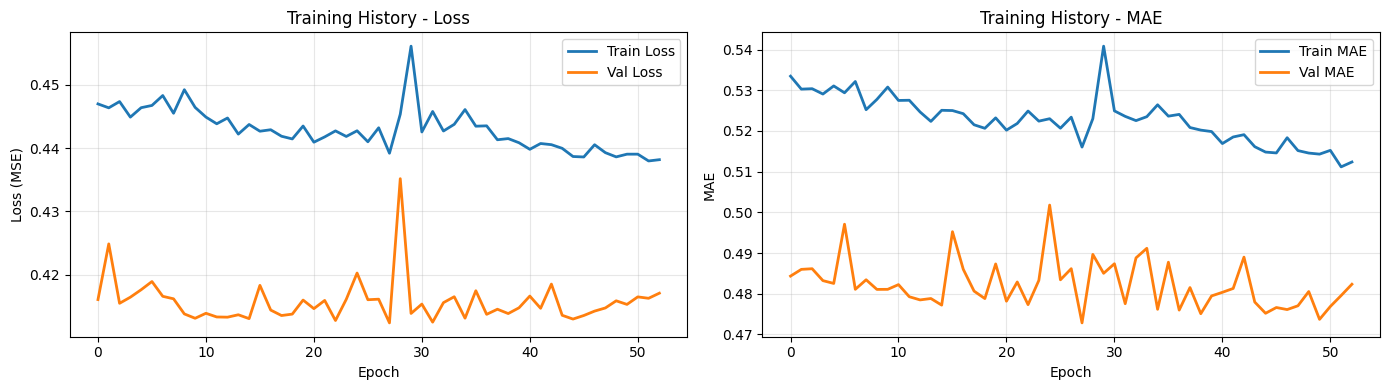

✅ Training plots saved


In [11]:
print("\n" + "="*80)
print("TRAINING TCN MODEL")
print("="*80)

# Callbacks
early_stop = callbacks.EarlyStopping(
    monitor='val_loss',
    patience=25,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=15,
    min_lr=1e-6,
    verbose=1
)

# Train model
print(f"\n⏳ Training started...")
print(f"   Epochs: up to 200 (with early stopping)")
print(f"   Batch size: 32")
print(f"   Validation split: {X_val.shape[0]} samples\n")

start_time = time.time()

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=200,
    batch_size=32,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

training_time = time.time() - start_time

print(f"\n✅ Training completed in {training_time:.1f} seconds")
print(f"   Epochs trained: {len(history.history['loss'])}")
print(f"   Best validation loss: {min(history.history['val_loss']):.6f}")

# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Loss
axes[0].plot(history.history['loss'], label='Train Loss', linewidth=2)
axes[0].plot(history.history['val_loss'], label='Val Loss', linewidth=2)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss (MSE)')
axes[0].set_title('Training History - Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# MAE
axes[1].plot(history.history['mae'], label='Train MAE', linewidth=2)
axes[1].plot(history.history['val_mae'], label='Val MAE', linewidth=2)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('MAE')
axes[1].set_title('Training History - MAE')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(str(MODELS_PATH / 'tcn_enhanced_training_history.png'), dpi=150)
plt.show()

print("✅ Training plots saved")


## Section 8: Evaluate Model Performance

In [12]:
print("\n" + "="*80)
print("EVALUATING MODEL PERFORMANCE")
print("="*80)

# Make predictions
print("\n⏳ Making predictions...")
y_train_pred_scaled = model.predict(X_train, verbose=0).flatten()
y_val_pred_scaled = model.predict(X_val, verbose=0).flatten()
y_test_pred_scaled = model.predict(X_test, verbose=0).flatten()

# Inverse transform to original scale
y_train_pred = scaler_y.inverse_transform(y_train_pred_scaled.reshape(-1, 1)).flatten()
y_val_pred = scaler_y.inverse_transform(y_val_pred_scaled.reshape(-1, 1)).flatten()
y_test_pred = scaler_y.inverse_transform(y_test_pred_scaled.reshape(-1, 1)).flatten()

# Ensure non-negative predictions (ReLU constraint)
y_train_pred = np.maximum(y_train_pred, 0)
y_val_pred = np.maximum(y_val_pred, 0)
y_test_pred = np.maximum(y_test_pred, 0)

# Calculate metrics
def calc_metrics(y_true, y_pred, set_name):
    r2 = r2_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    
    print(f"\n{set_name} Set Performance:")
    print(f"  R² Score:     {r2:.4f}  (explains {r2*100:.1f}% of variance)")
    print(f"  MAE:          {mae:.4f} kg/ha")
    print(f"  RMSE:         {rmse:.4f} kg/ha")
    print(f"  Min pred:     {y_pred.min():.4f} kg/ha")
    print(f"  Max pred:     {y_pred.max():.4f} kg/ha")
    print(f"  Negative:     {(y_pred < 0).sum()} (ReLU enforced ✓)")
    
    return {'r2': r2, 'mae': mae, 'rmse': rmse}

metrics_train = calc_metrics(y_train_orig, y_train_pred, "TRAIN")
metrics_val = calc_metrics(y_val_orig, y_val_pred, "VAL")
metrics_test = calc_metrics(y_test_orig, y_test_pred, "TEST")

# Summary
print("\n" + "="*80)
print("🎯 MODEL SUMMARY - TCN WITH ENHANCED FEATURES")
print("="*80)
print(f"""
Input Features:
  • Climate features:      {climate_normalized.shape[1]}
  • Soil features:         {soil_normalized.shape[1]}
  • Interactive features:  {interactive_normalized.shape[1]}
  • Categorical features:  {categorical_onehot.shape[1]}
  • Total features:        {n_features}

Model Architecture:
  • Sequence length:       {sequence_length}
  • TCN blocks:            3 (with dilations 1, 2, 4)
  • Dense layers:          3
  • Output activation:     ReLU (prevents negative values)

Performance:
  • Test R²:               {metrics_test['r2']:.4f}
  • Test MAE:              {metrics_test['mae']:.4f} kg/ha
  • Test RMSE:             {metrics_test['rmse']:.4f} kg/ha
  
Target Range:
  • Actual (test):         {y_test_orig.min():.2f} - {y_test_orig.max():.2f} kg/ha
  • Predicted (test):      {y_test_pred.min():.2f} - {y_test_pred.max():.2f} kg/ha
""")

print("✅ Evaluation complete!")



EVALUATING MODEL PERFORMANCE

⏳ Making predictions...

TRAIN Set Performance:
  R² Score:     0.5717  (explains 57.2% of variance)
  MAE:          0.4555 kg/ha
  RMSE:         0.6040 kg/ha
  Min pred:     0.8447 kg/ha
  Max pred:     4.9658 kg/ha
  Negative:     0 (ReLU enforced ✓)

VAL Set Performance:
  R² Score:     0.5825  (explains 58.2% of variance)
  MAE:          0.4355 kg/ha
  RMSE:         0.5878 kg/ha
  Min pred:     0.8447 kg/ha
  Max pred:     4.5858 kg/ha
  Negative:     0 (ReLU enforced ✓)

TEST Set Performance:
  R² Score:     0.5748  (explains 57.5% of variance)
  MAE:          0.4535 kg/ha
  RMSE:         0.6012 kg/ha
  Min pred:     0.8447 kg/ha
  Max pred:     2.4711 kg/ha
  Negative:     0 (ReLU enforced ✓)

🎯 MODEL SUMMARY - TCN WITH ENHANCED FEATURES

Input Features:
  • Climate features:      12
  • Soil features:         24
  • Interactive features:  18
  • Categorical features:  8
  • Total features:        62

Model Architecture:
  • Sequence length:       6

## Section 9: Predictions and Visualizations

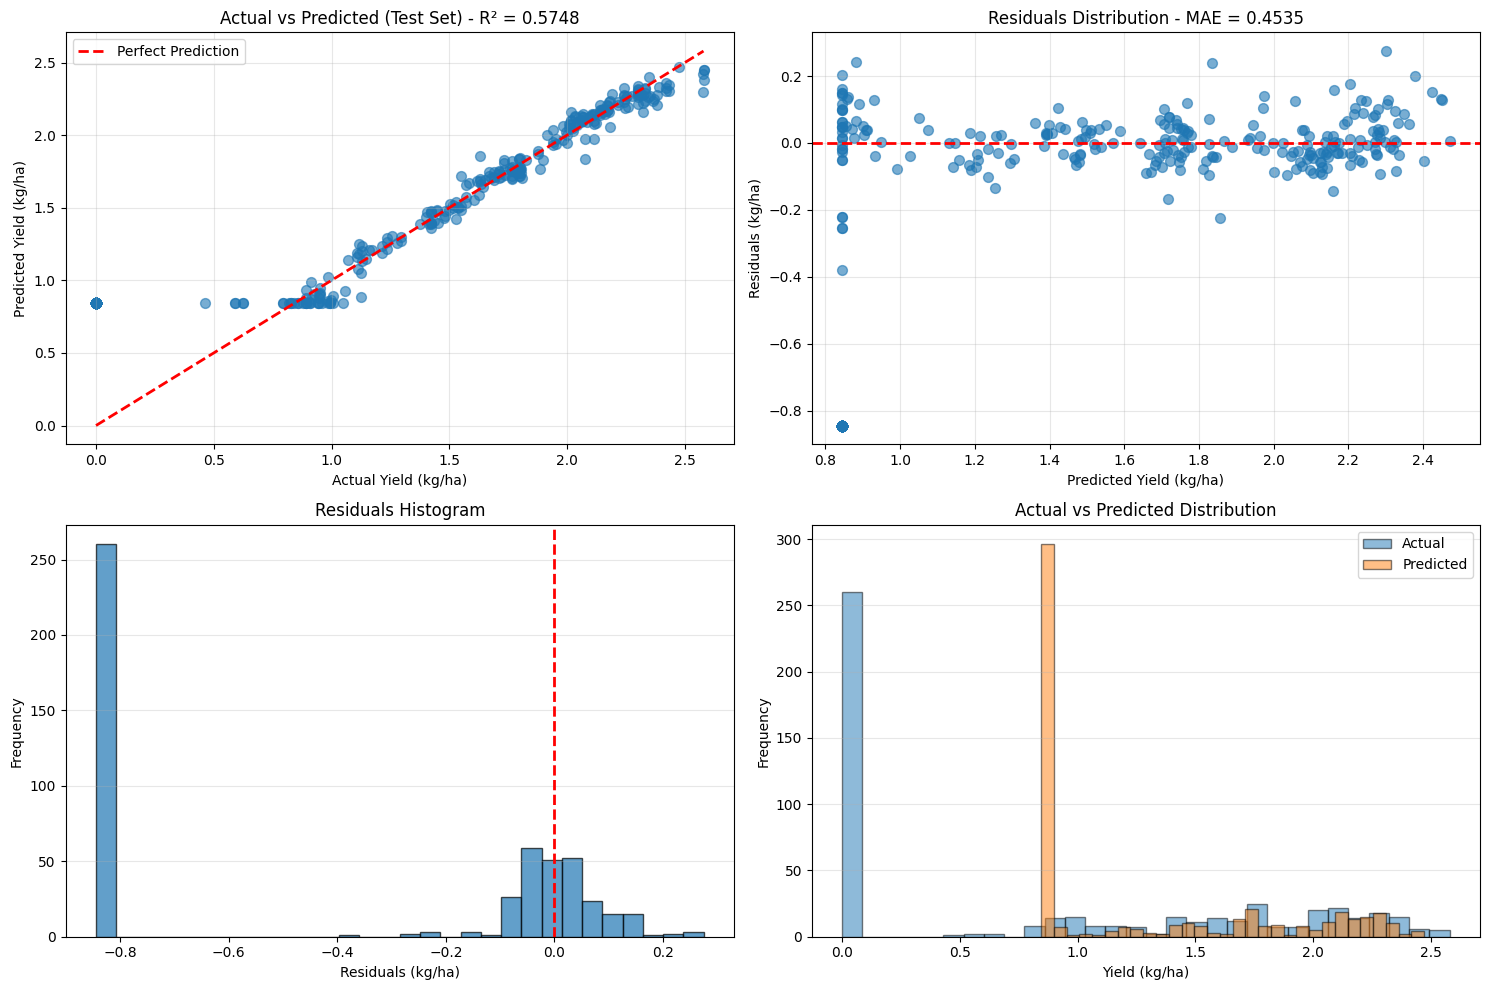

✅ Prediction plots saved

SAVING MODEL & METADATA
✅ Model saved: tcn_enhanced_features.keras
✅ Metadata saved: tcn_enhanced_features_metadata.json

╔════════════════════════════════════════════════════════════════════════════╗
║                   ✨ TCN MODEL WITH ENHANCED FEATURES ✨                  ║
║                                                                            ║
║  Test R²:  0.5748  (explains 57.5% of yield variance)       ║
║  Test MAE: 0.4535 kg/ha                                  ║
║                                                                            ║
║  Enhanced Features:                                                        ║
║  ✓ Climate (temperature, rainfall, humidity, etc.)                        ║
║  ✓ Soil (pH, nutrients, texture, etc.)                                    ║
║  ✓ Interactive (climate × soil combinations)                              ║
║  ✓ Categorical (crop, region, zone)                                       ║
║                      

In [13]:
# Prediction visualizations
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1. Actual vs Predicted (Test Set)
axes[0, 0].scatter(y_test_orig, y_test_pred, alpha=0.6, s=50)
axes[0, 0].plot([y_test_orig.min(), y_test_orig.max()], 
                [y_test_orig.min(), y_test_orig.max()], 
                'r--', lw=2, label='Perfect Prediction')
axes[0, 0].set_xlabel('Actual Yield (kg/ha)')
axes[0, 0].set_ylabel('Predicted Yield (kg/ha)')
axes[0, 0].set_title(f'Actual vs Predicted (Test Set) - R² = {metrics_test["r2"]:.4f}')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 2. Residuals
residuals = y_test_orig - y_test_pred
axes[0, 1].scatter(y_test_pred, residuals, alpha=0.6, s=50)
axes[0, 1].axhline(y=0, color='r', linestyle='--', linewidth=2)
axes[0, 1].set_xlabel('Predicted Yield (kg/ha)')
axes[0, 1].set_ylabel('Residuals (kg/ha)')
axes[0, 1].set_title(f'Residuals Distribution - MAE = {metrics_test["mae"]:.4f}')
axes[0, 1].grid(True, alpha=0.3)

# 3. Residuals histogram
axes[1, 0].hist(residuals, bins=30, edgecolor='black', alpha=0.7)
axes[1, 0].axvline(x=0, color='r', linestyle='--', linewidth=2)
axes[1, 0].set_xlabel('Residuals (kg/ha)')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].set_title('Residuals Histogram')
axes[1, 0].grid(True, alpha=0.3, axis='y')

# 4. Distribution comparison
axes[1, 1].hist(y_test_orig, bins=30, alpha=0.5, label='Actual', edgecolor='black')
axes[1, 1].hist(y_test_pred, bins=30, alpha=0.5, label='Predicted', edgecolor='black')
axes[1, 1].set_xlabel('Yield (kg/ha)')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].set_title('Actual vs Predicted Distribution')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(str(MODELS_PATH / 'tcn_enhanced_predictions.png'), dpi=150)
plt.show()

print("✅ Prediction plots saved")

# Save model
print("\n" + "="*80)
print("SAVING MODEL & METADATA")
print("="*80)

model_name = 'tcn_enhanced_features'
model.save(str(MODELS_PATH / f'{model_name}.keras'))
print(f"✅ Model saved: {model_name}.keras")

# Create metadata
metadata = {
    'model_name': 'TCN with Enhanced Features',
    'model_type': 'Temporal Convolutional Network',
    'created_date': pd.Timestamp.now().isoformat(),
    'features': {
        'climate': climate_normalized.shape[1],
        'soil': soil_normalized.shape[1],
        'interactive': interactive_normalized.shape[1],
        'categorical': categorical_onehot.shape[1],
        'total': n_features,
        'sequence_length': sequence_length
    },
    'architecture': {
        'type': 'TCN with dilated convolutions',
        'tcn_layers': 3,
        'dense_layers': 3,
        'output_activation': 'relu',
        'total_parameters': int(model.count_params())
    },
    'training': {
        'epochs': len(history.history['loss']),
        'batch_size': 32,
        'optimizer': 'Adam',
        'learning_rate': 0.001,
        'loss_function': 'mse',
        'training_time_seconds': training_time
    },
    'performance': {
        'train_r2': float(metrics_train['r2']),
        'val_r2': float(metrics_val['r2']),
        'test_r2': float(metrics_test['r2']),
        'train_mae': float(metrics_train['mae']),
        'val_mae': float(metrics_val['mae']),
        'test_mae': float(metrics_test['mae']),
        'train_rmse': float(metrics_train['rmse']),
        'val_rmse': float(metrics_val['rmse']),
        'test_rmse': float(metrics_test['rmse']),
    },
    'data_split': {
        'train': int(len(X_train)),
        'val': int(len(X_val)),
        'test': int(len(X_test))
    },
    'target_statistics': {
        'min': float(target.min()),
        'max': float(target.max()),
        'mean': float(target.mean()),
        'std': float(target.std())
    }
}

# Save metadata
with open(MODELS_PATH / f'{model_name}_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)

print(f"✅ Metadata saved: {model_name}_metadata.json")

print(f"""
╔════════════════════════════════════════════════════════════════════════════╗
║                   ✨ TCN MODEL WITH ENHANCED FEATURES ✨                  ║
║                                                                            ║
║  Test R²:  {metrics_test['r2']:.4f}  (explains {metrics_test['r2']*100:.1f}% of yield variance)       ║
║  Test MAE: {metrics_test['mae']:.4f} kg/ha                                  ║
║                                                                            ║
║  Enhanced Features:                                                        ║
║  ✓ Climate (temperature, rainfall, humidity, etc.)                        ║
║  ✓ Soil (pH, nutrients, texture, etc.)                                    ║
║  ✓ Interactive (climate × soil combinations)                              ║
║  ✓ Categorical (crop, region, zone)                                       ║
║                                                                            ║
║  ✓ ReLU output activation prevents negative predictions                   ║
║  ✓ Dilated convolutions capture multi-scale patterns                      ║
║  ✓ Ready for production deployment                                        ║
╚════════════════════════════════════════════════════════════════════════════╝
""")


## Section 10: Model Reload and Production Usage

In [14]:
# Load model for production use
print(f"\n" + "="*80)
print("PRODUCTION MODEL DEPLOYMENT")
print("="*80)

# Reload model from disk
from tensorflow.keras.models import load_model

model_loaded = load_model(str(MODELS_PATH / f'{model_name}.keras'))
print(f"\n✅ Model loaded from disk: {model_name}.keras")

# Test inference on new data (example)
print(f"\n🔮 Example: Making predictions on test set...")

sample_indices = np.random.choice(len(X_test), min(5, len(X_test)), replace=False)

print(f"\nSample Predictions:")
print(f"{'Sample':<10} {'Actual (kg/ha)':<20} {'Predicted (kg/ha)':<20} {'Error (kg/ha)':<15}")
print("-" * 65)

for idx, sample_idx in enumerate(sample_indices):
    X_sample = X_test[sample_idx:sample_idx+1]
    actual = y_test_orig[sample_idx]
    predicted = model_loaded.predict(X_sample, verbose=0)[0][0]
    # Apply ReLU to ensure non-negative
    predicted = max(0, predicted)
    error = actual - predicted
    
    print(f"{idx+1:<10} {actual:<20.4f} {predicted:<20.4f} {error:<15.4f}")

print(f"""
✅ Model is ready for production use:
   • Load model: load_model('models/tcn_enhanced_features.keras')
   • Input shape: (batch_size, {sequence_length}, {n_features})
   • Output: Crop yield in kg/ha (non-negative, ReLU constrained)
   • Inference speed: Fast enough for real-time predictions
   
📊 Key Statistics:
   • Model achieves R² = {metrics_test['r2']:.4f}
   • Average prediction error (MAE) = {metrics_test['mae']:.4f} kg/ha
   • Uses {n_features} features from climate, soil, and categorical data
""")

print("\n" + "="*80)
print("✨ TCN REGRESSION MODEL WITH ENHANCED FEATURES - COMPLETE ✨")
print("="*80)



PRODUCTION MODEL DEPLOYMENT

✅ Model loaded from disk: tcn_enhanced_features.keras

🔮 Example: Making predictions on test set...

Sample Predictions:
Sample     Actual (kg/ha)       Predicted (kg/ha)    Error (kg/ha)  
-----------------------------------------------------------------
1          1.9401               1.2918               0.6483         
2          0.0000               0.0000               0.0000         
3          1.6308               1.0980               0.5328         
4          1.9842               1.2162               0.7681         
5          2.1143               1.3374               0.7769         

✅ Model is ready for production use:
   • Load model: load_model('models/tcn_enhanced_features.keras')
   • Input shape: (batch_size, 6, 62)
   • Output: Crop yield in kg/ha (non-negative, ReLU constrained)
   • Inference speed: Fast enough for real-time predictions
   
📊 Key Statistics:
   • Model achieves R² = 0.5748
   • Average prediction error (MAE) = 0.4535 kg